Setup & Data Load

In [20]:
!pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Loading datasets

In [21]:
mock_users = pd.read_csv('/content/drive/MyDrive/Quiz Forge/mock_users.csv')
mock_quizzes = pd.read_csv('/content/drive/MyDrive/Quiz Forge/mock_quizzes.csv')

print(mock_users.head())
print(mock_quizzes.head())

  user_id signup_date         user_persona subscription_plan last_login_date  \
0  QF1000  03-03-2024  High School Teacher              Free      30-08-2024   
1  QF1001  03-03-2024  High School Teacher        Enterprise      17-08-2024   
2  QF1002  03-04-2024      Content Creator               Pro      13-08-2024   
3  QF1003  03-05-2024  Language Instructor              Free      29-08-2024   
4  QF1004  03-06-2024      HR Professional              Free      14-08-2024   

   quizzes_created  is_active signup_month  days_since_signup  \
0                7      False      2024-03                181   
1               65       True      2024-03                181   
2               15       True      2024-03                180   
3                8       True      2024-03                179   
4                2       True      2024-03                178   

   days_since_last_login  
0                      5  
1                     14  
2                     18  
3                   

Feature Engineering

In [35]:
# Derive number of quizzes created by each user
quiz_counts = mock_quizzes.groupby('creator_id')['quiz_id'].count().reset_index()
quiz_counts.columns = ['creator_id', 'quizzes_created']

# Merge with user data
users_features = mock_users.merge(quiz_counts, left_on='user_id', right_on='creator_id', how='left')

# Fill missing values from both possible sources
if 'quizzes_created_x' in users_features.columns and 'quizzes_created_y' in users_features.columns:
    # Combine: if quizzes_created_y is NaN, use quizzes_created_x
    users_features['quizzes_created'] = users_features['quizzes_created_y'].fillna(users_features['quizzes_created_x'])
    users_features.drop(columns=['quizzes_created_x', 'quizzes_created_y'], inplace=True)
elif 'quizzes_created_y' in users_features.columns:
    users_features.rename(columns={'quizzes_created_y': 'quizzes_created'}, inplace=True)
elif 'quizzes_created_x' in users_features.columns:
    users_features.rename(columns={'quizzes_created_x': 'quizzes_created'}, inplace=True)

# Drop creator_id since it’s just for merging
users_features.drop(columns=['creator_id'], inplace=True, errors='ignore')

# Fill missing quiz counts with 0
users_features['quizzes_created'] = users_features['quizzes_created'].fillna(0)

# Compute tenure (days since signup)
users_features['signup_date'] = pd.to_datetime(users_features['signup_date'], errors='coerce')
users_features['tenure_days'] = (pd.Timestamp.now() - users_features['signup_date']).dt.days

users_features.head()

,user_id,signup_date,user_persona,subscription_plan,last_login_date,is_active,signup_month,days_since_signup,days_since_last_login,quizzes_created,tenure_days
0,QF1000,2024-03-03,High School Teacher,Free,30-08-2024,False,2024-03,181,5,4.0,603.0
1,QF1001,2024-03-03,High School Teacher,Enterprise,17-08-2024,True,2024-03,181,14,11.0,603.0
2,QF1002,2024-03-04,Content Creator,Pro,13-08-2024,True,2024-03,180,18,2.0,602.0
3,QF1003,2024-03-05,Language Instructor,Free,29-08-2024,True,2024-03,179,2,2.0,601.0
4,QF1004,2024-03-06,HR Professional,Free,14-08-2024,True,2024-03,178,17,2.0,600.0


Data Preprocessing

In [36]:
X = users_features[['quizzes_created', 'tenure_days']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.09272672,  1.35261867],
       [ 2.11480462,  1.35261867],
       [-0.48500983,  1.33945922],
       [-0.48500983,  1.32629978],
       [-0.48500983,  1.31314033]])

Determine Optimal Number of Clusters (Elbow Method)

In [38]:
from sklearn.preprocessing import StandardScaler

X = users_features[['quizzes_created', 'tenure_days']].copy()

X = X.fillna(0)   # Option 1: Replace NaN with 0
# or X = X.fillna(X.mean())  # Option 2: Replace with column means (better if 0 is not meaningful)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

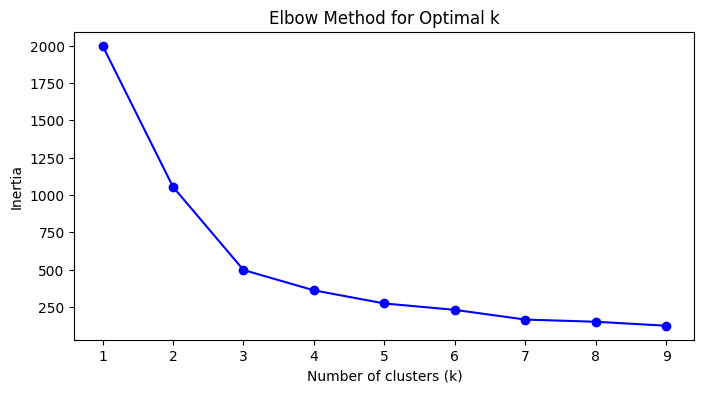

In [39]:
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Run KMeans Clustering

In [40]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
users_features['segment'] = kmeans.fit_predict(X_scaled)

users_features[['user_id', 'quizzes_created', 'tenure_days', 'segment']].head()

,user_id,quizzes_created,tenure_days,segment
0,QF1000,4.0,603.0,1
1,QF1001,11.0,603.0,0
2,QF1002,2.0,602.0,1
3,QF1003,2.0,601.0,1
4,QF1004,2.0,600.0,1


Visualize Clusters

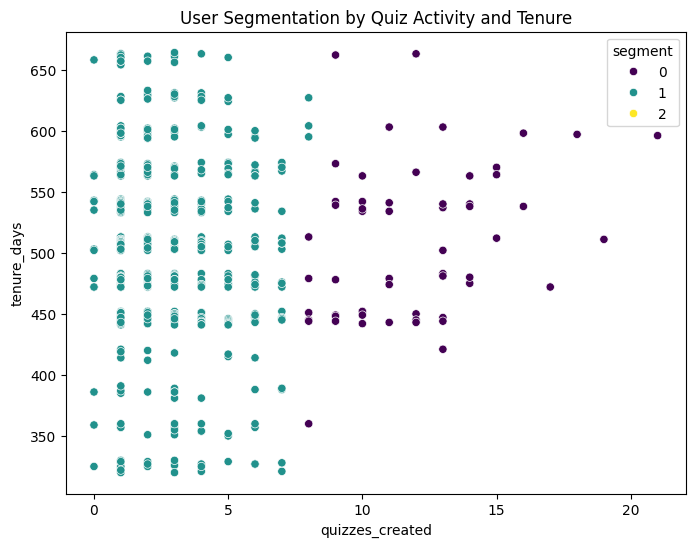

In [41]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='quizzes_created',
    y='tenure_days',
    hue='segment',
    palette='viridis',
    data=users_features
)
plt.title('User Segmentation by Quiz Activity and Tenure')
plt.show()

In [43]:
users_features.to_csv('/content/mock_users_with_segments.csv', index=False)
print("Saved mock_users_with_segments.csv successfully!")

Saved mock_users_with_segments.csv successfully!
